#**Exercise 1: Duplicate Detection and Removal**

In [1]:
!pip install kaggle

In [2]:

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c titanic

!unzip titanic.zip

Saving kaggle.json to kaggle.json
  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 110MB/s]
Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [3]:
import pandas as pd
import numpy as np
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
# df_train.info()
print("Train shape before:", df_train.shape)
print("Test shape before:", df_test.shape)

print("The train data has duplications : ",df_train.duplicated().sum())
print("The test data has duplications : ",df_test.duplicated().sum())

df_train.drop_duplicates(inplace=True)
df_test.drop_duplicates(inplace=True)

print("Train shape before:", df_train.shape)
print("Test shape before:", df_test.shape)

print("The train data has duplications : ",df_train.duplicated().sum())
print("The test data has duplications : ",df_test.duplicated().sum())



Train shape before: (891, 12)
Test shape before: (418, 11)
The train data has duplications :  0
The test data has duplications :  0
Train shape before: (891, 12)
Test shape before: (418, 11)
The train data has duplications :  0
The test data has duplications :  0


#**Exercise 2: Handling Missing Values**

In [16]:
#For training data
print(df_train.info())
#df_train.isnull().sum()[df_train.isnull().sum() == 0]
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
df_train_drop_all_na = df_train.dropna()
print(df_train_drop_all_na.info())
sstd = df_train['Age'].std()
#print(sstd)
moode = df_train['Cabin'].mode()
#print(moode)

df_train_fill_na = df_train.fillna({
    'Age' : df_train['Age'].mean(),
    "Cabin" : df_train['Cabin'].mode().iloc[0],
    #'Cabin': 'Unknown'

    "Embarked" : df_train['Embarked'].mode().iloc[0],
    })
print(df_train_fill_na.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Survived      891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Name          891 non-null    object 
 4   Sex           891 non-null    object 
 5   Age           714 non-null    float64
 6   SibSp         891 non-null    int64  
 7   Parch         891 non-null    int64  
 8   Ticket        891 non-null    object 
 9   Fare          891 non-null    float64
 10  Cabin         204 non-null    object 
 11  Embarked      889 non-null    object 
 12  FamilySize    891 non-null    int64  
 13  Title_Master  891 non-null    bool   
 14  Title_Miss    891 non-null    bool   
 15  Title_Mr      891 non-null    bool   
 16  Title_Mrs     891 non-null    bool   
 17  Title_Rare    891 non-null    bool   
 18  Title         891 non-null    

In [5]:
#For test data
print(df_test.info())

print(df_test.isnull().sum()[df_test.isnull().sum() > 0])
df_test_drop_all_na = df_test.dropna()
print(df_test_drop_all_na.info())
sstd = df_test['Age'].std()

moode = df_test['Cabin'].mode()


df_test_fill_na = df_test.fillna({
    'Age' : df_test['Age'].mean(),
    "Cabin" : df_test['Cabin'].mode().iloc[0],
    "Embarked" : df_test['Embarked'].mode().iloc[0],
    })
print(df_test_fill_na.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None
Age       86
Fare       1
Cabin    327
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 12 to 414
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  87 non-null     int64  
 1 

#**Exercise 3: Feature Engineering**


In [ ]:
# df_train.head()
# df_train['Familysize'] = df_train['SibSp'] + df_train['Parch'] + 1
# df_test['Familysize'] = df_test['SibSp'] + df_test['Parch'] + 1
# df_train.head()
# df_train['Title'] = df_train['Name'].str.extract(r', ([A-Za-z]+)\.', expand=False)
# df_test['Title'] = df_test['Name'].str.extract(r', ([A-Za-z]+)\.', expand=False)
# df_train.head()
# unique_titles = df_train['Title'].unique()
# print(unique_titles)
# unique_Familysize = df_train['Familysize'].unique()
# print(unique_Familysize)

# unique_Sex = df_train['Sex'].unique()
# print(unique_Sex)

# df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})
# df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})

# unique_Embarked = df_train['Embarked'].unique()
# print(unique_Embarked)
# df_train['Embarked'] = df_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
# df_test['Embarked'] = df_test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# unique_cabin = df_train['Cabin'].unique()
# print(unique_cabin)
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df_train['Title'] = le.fit_transform(df_train['Title'])
# df_test['Title'] = le.transform(df_test['Title'])

# df_train = pd.get_dummies(df_train, columns=['Title'])
# df_test = pd.get_dummies(df_test, columns=['Title'])

# print(df_train.head())
# print(df_test.head())

In [21]:
df_trainN= df_train['Name'].str.extract(r', ([A-Za-z]+)\.', expand=False)
print(set(df_trainN))


{'Mrs', nan, 'Rev', 'Don', 'Mme', 'Lady', 'Capt', 'Dr', 'Jonkheer', 'Master', 'Miss', 'Sir', 'Ms', 'Major', 'Col', 'Mr', 'Mlle'}


In [22]:
# Family Size
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1

# Title from Name
df_train['Title'] = df_train['Name'].str.extract(r', ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Name'].str.extract(r', ([A-Za-z]+)\.', expand=False)


df_train['Title'] = df_train['Title'].fillna(df_train['Title'].mode()[0])#mode() returns serie
df_test['Title']  = df_test['Title'].fillna(df_test['Title'].mode()[0])

print(set(df_train['Title']))


rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona','Master']
df_train['Title'] = df_train['Title'].replace(rare_titles, 'Rare')
df_test['Title'] = df_test['Title'].replace(rare_titles, 'Rare')

# Normalize similar titles
df_train['Title'] = df_train['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
df_test['Title'] = df_test['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

df_train = pd.get_dummies(df_train, columns=['Title'], prefix='Title')
df_test = pd.get_dummies(df_test, columns=['Title'], prefix='Title')

df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

{'Mrs', 'Rev', 'Don', 'Mme', 'Lady', 'Capt', 'Dr', 'Jonkheer', 'Master', 'Miss', 'Sir', 'Ms', 'Major', 'Col', 'Mr', 'Mlle'}


In [5]:
df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})

# --- Encode Embarked ---
df_train['Embarked'] = df_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df_test['Embarked'] = df_test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# --- Check results ---
print(df_train.head())
print(df_test.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin  Embarked  FamilySize  Title_Master  \
0         A/5 21171   7.2500   NaN       0.0           2         False   
1          PC 17599  71.2833   C85       1.0           2         False   
2  STON/O2. 3101282   7.9250   NaN       0.0           1         False   


#**Exercise 4: Outlier Detection and Handling**

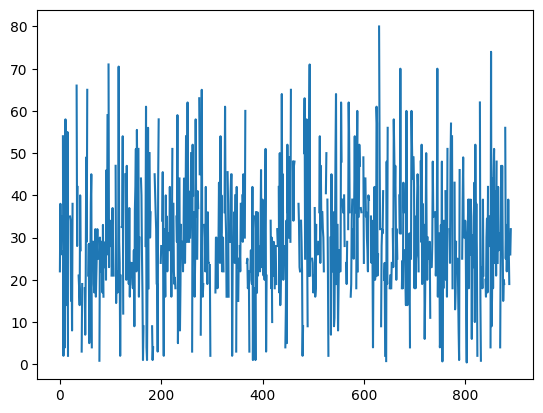

In [19]:
import matplotlib.pyplot as plt

plt.plot(df_train['Age'])
plt.show()


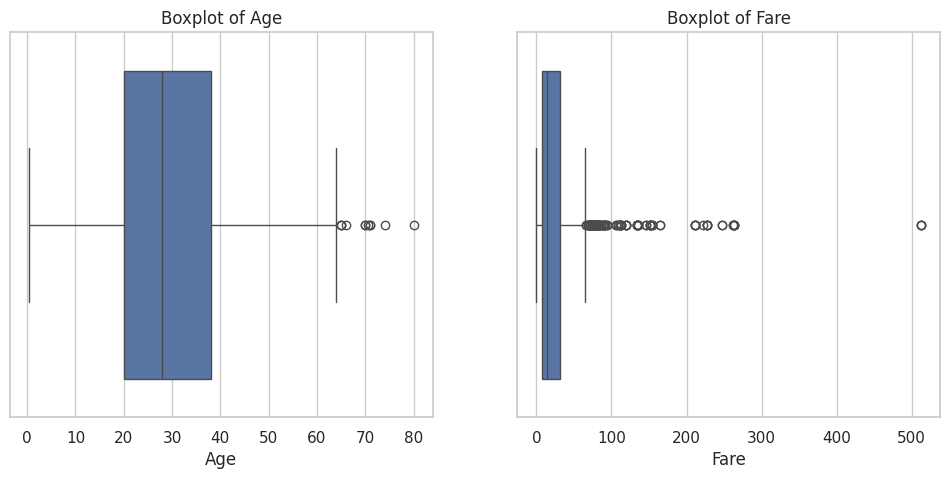

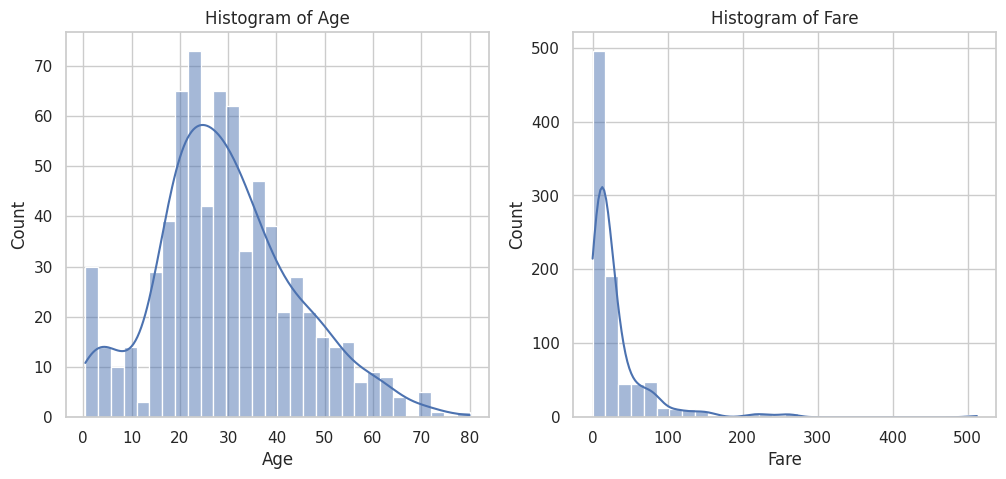

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# --- Boxplots ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df_train['Age'])
plt.title("Boxplot of Age")

plt.subplot(1,2,2)
sns.boxplot(x=df_train['Fare'])
plt.title("Boxplot of Fare")

plt.show()

# --- Histograms ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_train['Age'], bins=30, kde=True)
plt.title("Histogram of Age")

plt.subplot(1,2,2)
sns.histplot(df_train['Fare'], bins=30, kde=True)
plt.title("Histogram of Fare")

plt.show()


In [7]:
# IQR method
Q1_age, Q3_age = df_train['Age'].quantile([0.25, 0.75])
IQR_age = Q3_age - Q1_age
lower_age, upper_age = Q1_age - 1.5*IQR_age, Q3_age + 1.5*IQR_age

Q1_fare, Q3_fare = df_train['Fare'].quantile([0.25, 0.75])
IQR_fare = Q3_fare - Q1_fare
lower_fare, upper_fare = Q1_fare - 1.5*IQR_fare, Q3_fare + 1.5*IQR_fare

print("Age outlier bounds:", lower_age, upper_age)
print("Fare outlier bounds:", lower_fare, upper_fare)


Age outlier bounds: -6.6875 64.8125
Fare outlier bounds: -26.724 65.6344


In [8]:
from scipy import stats
import numpy as np

z_scores_age = np.abs(stats.zscore(df_train['Age'].dropna()))$
z_scores_fare = np.abs(stats.zscore(df_train['Fare'].dropna()))

outliers_age = df_train['Age'][z_scores_age > 3]
outliers_fare = df_train['Fare'][z_scores_fare > 3]

print("Age outliers (Z-score):", outliers_age)
print("Fare outliers (Z-score):", outliers_fare)


IndexError: Boolean index has wrong length: 714 instead of 891

In [9]:
cap_age = df_train['Age'].quantile(0.98)
cap_fare = df_train['Fare'].quantile(0.98)

df_train['Age_capped'] = np.where(df_train['Age'] > cap_age, cap_age, df_train['Age'])
df_train['Fare_capped'] = np.where(df_train['Fare'] > cap_fare, cap_fare, df_train['Fare'])


In [10]:
cap_age = df_train['Age'].quantile(0.98)
cap_fare = df_train['Fare'].quantile(0.98)

df_train['Age_capped'] = np.where(df_train['Age'] > cap_age, cap_age, df_train['Age'])
df_train['Fare_capped'] = np.where(df_train['Fare'] > cap_fare, cap_fare, df_train['Fare'])


In [11]:
df_train['Fare_log'] = np.log1p(df_train['Fare'])  # log(1+Fare)


In [12]:
df_train_removed = df_train[(df_train['Fare'] <= cap_fare) & (df_train['Age'] <= cap_age)]


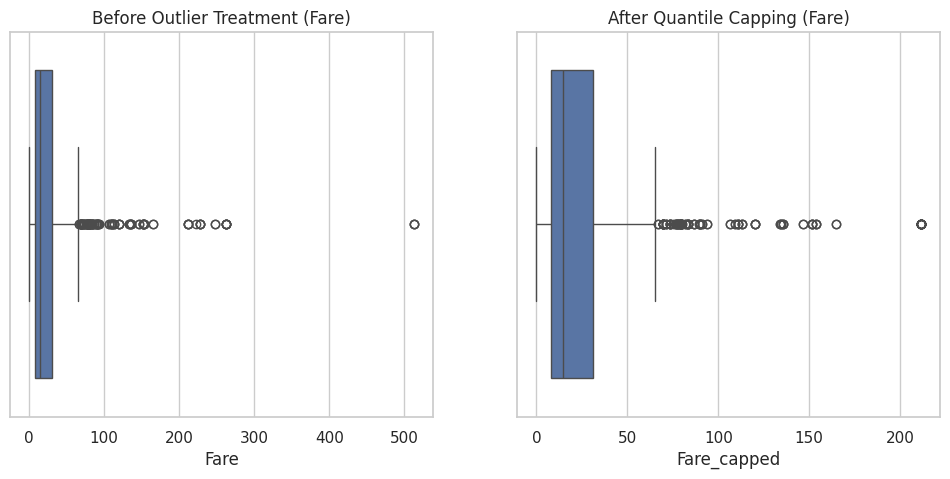

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df_train['Fare'])
plt.title("Before Outlier Treatment (Fare)")

plt.subplot(1,2,2)
sns.boxplot(x=df_train['Fare_capped'])
plt.title("After Quantile Capping (Fare)")

plt.show()


#**Exercise 5: Data Standardization and Normalization**


In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# --- Select features ---
num_features_standard = ['Age']          # normally distributed
num_features_minmax = ['Fare', 'FamilySize']  # skewed or bounded

# --- Initialize scalers ---
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# --- Fit & transform train ---
df_train[num_features_standard] = scaler_standard.fit_transform(df_train[num_features_standard])
df_train[num_features_minmax] = scaler_minmax.fit_transform(df_train[num_features_minmax])

# --- Transform test (use same fit) ---
df_test[num_features_standard] = scaler_standard.transform(df_test[num_features_standard])
df_test[num_features_minmax] = scaler_minmax.transform(df_test[num_features_minmax])


In [15]:
print(df_train[['Age','Fare','FamilySize']].describe())


                Age        Fare  FamilySize
count  7.140000e+02  891.000000  891.000000
mean   2.388379e-16    0.062858    0.090460
std    1.000701e+00    0.096995    0.161346
min   -2.016979e+00    0.000000    0.000000
25%   -6.595416e-01    0.015440    0.000000
50%   -1.170488e-01    0.028213    0.000000
75%    5.718310e-01    0.060508    0.100000
max    3.465126e+00    1.000000    1.000000


#**Exercise 6: Feature Encoding**

In [ ]:
import pandas as pd

# --- One-hot encode Title ---
df_train = pd.get_dummies(df_train, columns=['Title'], prefix='Title')
df_test = pd.get_dummies(df_test, columns=['Title'], prefix='Title')

# --- Align train and test so they have identical columns ---
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)


#**Exercise 7: Data Transformation for Age Feature**


In [ ]:
import pandas as pd

# Define bins and labels
bins = [0, 12, 18, 60, 100]   # ranges
labels = ['Child', 'Teen', 'Adult', 'Senior']

# Apply pd.cut to train and test
df_train['AgeGroup'] = pd.cut(df_train['Age'], bins=bins, labels=labels, right=False)
df_test['AgeGroup'] = pd.cut(df_test['Age'], bins=bins, labels=labels, right=False)


In [ ]:
# One-hot encode AgeGroup
df_train = pd.get_dummies(df_train, columns=['AgeGroup'], prefix='AgeGroup')
df_test = pd.get_dummies(df_test, columns=['AgeGroup'], prefix='AgeGroup')

# Align train and test so they have identical columns
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)


In [ ]:
print(df_train[['Age','AgeGroup_Child','AgeGroup_Teen','AgeGroup_Adult','AgeGroup_Senior']].head())
